In [1]:
# notebook to test if my npz files work

In [2]:
# keep autoreload but exclude jax-dependent modules
%reload_ext autoreload
%autoreload 2
%aimport -jax
%aimport -jaxlib
%aimport -adam_core

In [3]:
import velocity_density_pipeline as vdp

pms = vdp.ProbMapSet.from_npz("prob_maps_2025-03-21.npz")

# Case 1: single asteroid — no scorer needed
probs = pms.score_observation(
    ra_deg=183.2, dec_deg=-1.5,
    dra_deg_day=-0.35, ddec_deg_day=0.04,
    mag_app=21.7,
)
print(probs["NEO"])  # P(NEO) for this object

# Case 2: bulk S3M for ROC — scorer IS needed here (for propagation)
neo_df, scorer_neo = vdp.load_s3m_population("neo")
probs, visible_df = pms.score_orbital_df(neo_df, scorer=scorer_neo)
# visible_df has P_NEO, P_MBA, P_TNO, P_Trojans columns -> ready for ROC

[0.24315109]


Propagate with newton: 100%|██████████| 3/3 [00:00<00:00, 24.66it/s]


In [5]:
# ── Cell A: score all 4 populations and save the parquet ──────────────────
# (run this ONCE — it's slow, it's doing the propagation)
import velocity_density_pipeline as vdp
import pandas as pd

pms = vdp.ProbMapSet.from_npz("prob_maps_2025-03-21.npz")

populations = {
    "NEO":     "neo",
    "MBA":     "mba",
    "TNO":     "tno",
    "Trojans": "trojan",
}

scored_dfs = []
for pop_label, s3m_key in populations.items():
    print(f"\n{'='*60}\nScoring {pop_label}...")
    df, scorer = vdp.load_s3m_population(s3m_key)
    probs, visible_df = pms.score_orbital_df(
    df, scorer=scorer,
    chunk=500_000,
    apply_mask=False,   # ← key change for ROC
)
    visible_df["true_population"] = pop_label
    scored_dfs.append(visible_df)

all_scored = pd.concat(scored_dfs, ignore_index=True)

cols = ["true_population", "vlam", "vbeta", "mag_app",
        "mag_bin_label", "H", "P_NEO", "P_MBA", "P_TNO", "P_Trojans"]
all_scored = all_scored[cols]

print(f"\nTotal visible: {len(all_scored)}")
print(all_scored["true_population"].value_counts())

all_scored.to_parquet("s3m_scored_2025-03-21.parquet", index=False)
print("Saved!")


Scoring NEO...


Propagate with newton: 100%|██████████| 1/1 [00:05<00:00,  5.37s/it]



Scoring MBA...


Propagate with newton: 100%|██████████| 28/28 [00:06<00:00,  4.42it/s]



Scoring TNO...


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00, 45.54it/s]



Scoring Trojans...


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00, 13.50it/s]



Total visible: 1454634
true_population
MBA        1410105
Trojans      23605
NEO          13497
TNO           7427
Name: count, dtype: int64
Saved!


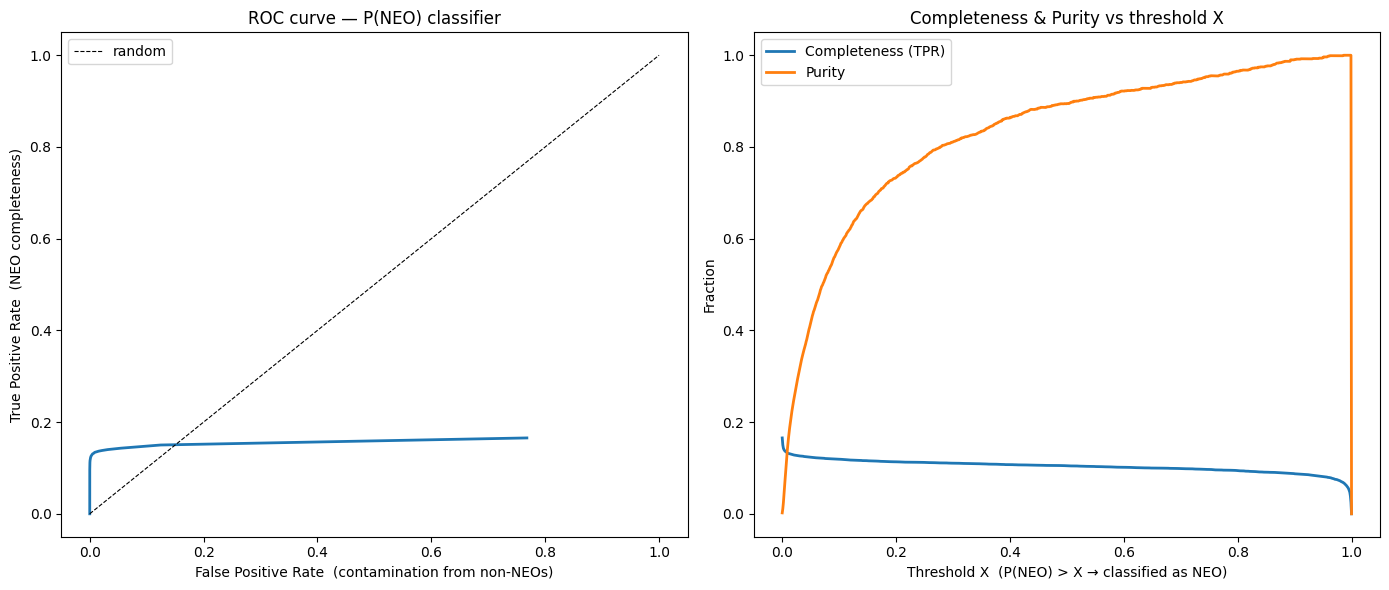

Optimal X* (max F1) = 0.137  (completeness=0.116, purity=0.659)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("s3m_scored_2025-03-21.parquet")

# ── ROC curve ─────────────────────────────────────────────────────────────
# positives = true NEOs, negatives = everything else
is_neo  = df["true_population"] == "NEO"
p_neo   = df["P_NEO"].to_numpy()

N_pos = is_neo.sum()        # total NEOs visible
N_neg = (~is_neo).sum()     # total non-NEOs visible

thresholds = np.linspace(0, 1, 1001)
TPR = np.array([(p_neo[is_neo]  > X).sum() / N_pos for X in thresholds])
FPR = np.array([(p_neo[~is_neo] > X).sum() / N_neg for X in thresholds])

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curve
ax = axes[0]
ax.plot(FPR, TPR, lw=2, color="tab:blue")
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="random")
ax.set_xlabel("False Positive Rate  (contamination from non-NEOs)")
ax.set_ylabel("True Positive Rate  (NEO completeness)")
ax.set_title("ROC curve — P(NEO) classifier")
ax.legend()

# Completeness + Purity vs threshold X
# purity = fraction of objects above threshold that are truly NEOs
purity = np.array([
    is_neo[p_neo > X].sum() / max((p_neo > X).sum(), 1)
    for X in thresholds
])
completeness = TPR  # same as TPR by definition

ax2 = axes[1]
ax2.plot(thresholds, completeness, lw=2, label="Completeness (TPR)", color="tab:blue")
ax2.plot(thresholds, purity,      lw=2, label="Purity",              color="tab:orange")
ax2.set_xlabel("Threshold X  (P(NEO) > X → classified as NEO)")
ax2.set_ylabel("Fraction")
ax2.set_title("Completeness & Purity vs threshold X")
ax2.legend()

plt.tight_layout()
plt.savefig("roc_curve.pdf", dpi=150)
plt.show()

# ── Find optimal threshold X* ─────────────────────────────────────────────
# maximise F1-score as one principled choice; swap for your science requirement
f1 = 2 * (purity * completeness) / np.maximum(purity + completeness, 1e-9)
i_star = np.argmax(f1)
X_star = thresholds[i_star]
print(f"Optimal X* (max F1) = {X_star:.3f}  "
      f"(completeness={completeness[i_star]:.3f}, purity={purity[i_star]:.3f})")